In [1]:
!pip install earthengine-api geemap rasterio scikit-image

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 37.0 MB/s eta 0:00:00


In [2]:
import ee

ee.Authenticate()

ee.Initialize(project='gen-lang-client-0412024487') # Replace 'your-project-id' with your actual Google Cloud Project ID

In [3]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import os

BASE = "/content/drive/MyDrive/PyroRL_Saudi_Project/datasets"

folders = [
    "saudi_eastern_province/raw/ndvi/vegetation",

    "saudi_eastern_province/processed/fuel",

    "saudi_eastern_province/grids/32x32",

    "saudi_eastern_province/grids/64x64"
]

for folder in folders:
    os.makedirs(os.path.join(BASE, folder), exist_ok=True)

print("NDVI folders created.")

NDVI folders created.


In [5]:
saudi_roi = ee.Geometry.Rectangle([
    45.5,
    23.5,
    50.5,
    28.5
])

In [6]:
modis = ee.ImageCollection("MODIS/061/MOD13Q1")

In [7]:
ndvi_collection = (
    modis
    .filterDate('2025-06-01', '2025-06-30')
    .select('NDVI')
)

In [8]:
ndvi = ndvi_collection.mean()

In [9]:
ndvi_saudi = ndvi.clip(saudi_roi)

In [10]:
import geemap

Map = geemap.Map(center=[26.5, 49], zoom=6)

ndvi_vis = {
    'min': 0,
    'max': 9000,
    'palette': [
        'white',
        'yellow',
        'green',
        'darkgreen'
    ]
}

Map.addLayer(ndvi_saudi, ndvi_vis, "Saudi NDVI")

Map

Map(center=[26.5, 49], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright', tr…

In [11]:
import geemap

output_tif = "/content/drive/MyDrive/PyroRL_Saudi_Project/datasets/saudi_eastern_province/raw/ndvi/vegetation/saudi_ndvi.tif"

geemap.ee_export_image(
    ndvi_saudi,
    filename=output_tif,
    scale=250,
    region=saudi_roi,
    file_per_band=False
)

print("NDVI exported.")

Generating URL ...
Please wait ...
Data downloaded to /content/drive/MyDrive/PyroRL_Saudi_Project/datasets/saudi_eastern_province/raw/ndvi/vegetation/saudi_ndvi.tif
NDVI exported.


In [12]:
import os

print(os.path.exists(output_tif))

True


In [13]:
import rasterio

src = rasterio.open(output_tif)

ndvi_data = src.read(1)

print(ndvi_data.shape)

(2237, 2227)


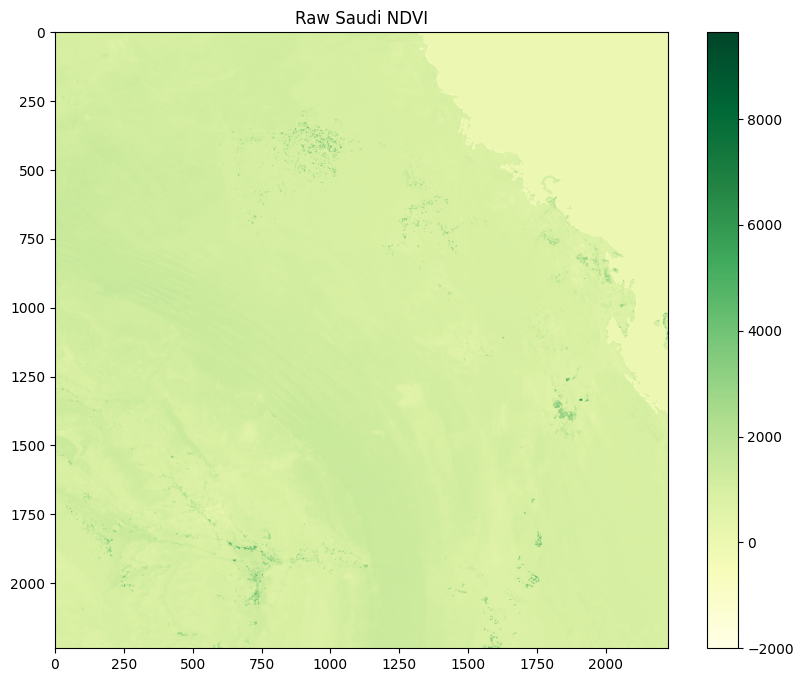

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

plt.imshow(ndvi_data, cmap='YlGn')

plt.title("Raw Saudi NDVI")

plt.colorbar()

plt.show()

In [15]:
import numpy as np

ndvi_data = ndvi_data.astype(np.float32)

ndvi_data = np.nan_to_num(ndvi_data)

In [17]:
ndvi_scaled = ndvi_data * 0.0001

In [18]:
print("Min:", ndvi_scaled.min())

print("Max:", ndvi_scaled.max())

print("Mean:", ndvi_scaled.mean())

Min: -0.19999999
Max: 0.96389997
Mean: 0.09363282


In [19]:
fuel_map = (ndvi_scaled + 1) / 2

In [20]:
fuel_map = np.clip(fuel_map, 0, 1)

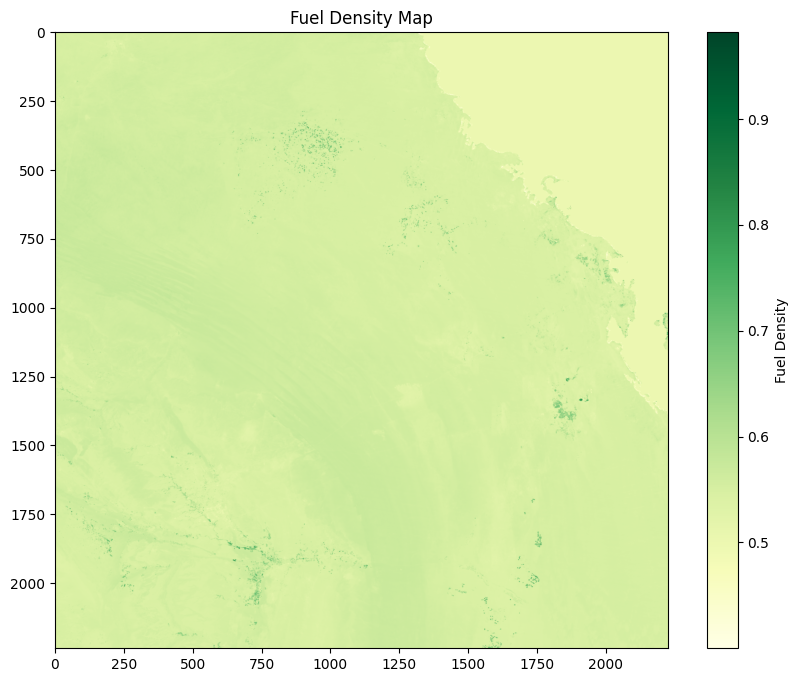

In [21]:
plt.figure(figsize=(10,8))

plt.imshow(fuel_map, cmap='YlGn')

plt.title("Fuel Density Map")

plt.colorbar(label="Fuel Density")

plt.show()

In [22]:
!pip install scikit-image

In [23]:
from skimage.transform import resize

In [24]:
fuel_32 = resize(
    fuel_map,
    (32,32),
    anti_aliasing=False
)

fuel_64 = resize(
    fuel_map,
    (64,64),
    anti_aliasing=False
)

In [25]:
print(fuel_32.shape)

print(fuel_64.shape)

(32, 32)
(64, 64)


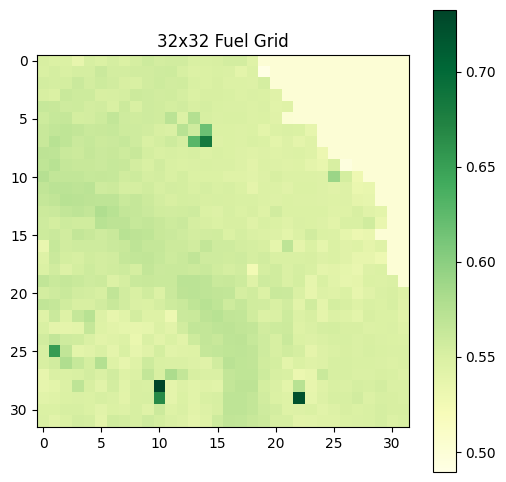

In [26]:
plt.figure(figsize=(6,6))

plt.imshow(fuel_32, cmap='YlGn')

plt.title("32x32 Fuel Grid")

plt.colorbar()

plt.show()

In [27]:
GRID_BASE = "/content/drive/MyDrive/PyroRL_Saudi_Project/datasets/saudi_eastern_province/grids"

np.save(
    f"{GRID_BASE}/32x32/fuel.npy",
    fuel_32
)

np.save(
    f"{GRID_BASE}/64x64/fuel.npy",
    fuel_64
)

print("Fuel grids saved.")

Fuel grids saved.


In [28]:
import os

print(os.listdir(f"{GRID_BASE}/32x32"))

['wind_x.npy', 'wind_y.npy', 'temperature.npy', 'humidity.npy', 'fuel.npy', 'state_tensor.npy', 'terrain.npy']


In [29]:
fuel_test = np.load(f"{GRID_BASE}/32x32/fuel.npy")

print(fuel_test.shape)

print(fuel_test.min())

print(fuel_test.max())

(32, 32)
0.48953882
0.7323682


FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/PyroRL_Saudi_Project/visualizations/fuel_32.png'

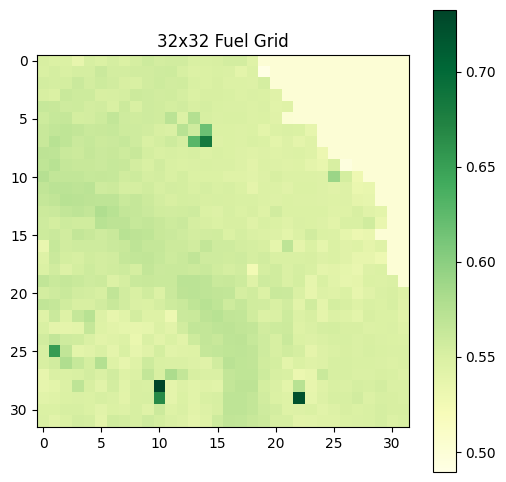

In [30]:
save_path = "/content/drive/MyDrive/PyroRL_Saudi_Project/visualizations/fuel_32.png"

plt.figure(figsize=(6,6))

plt.imshow(fuel_32, cmap='YlGn')

plt.title("32x32 Fuel Grid")

plt.colorbar()

plt.savefig(save_path, dpi=300)

plt.show()

print("Visualization saved.")

In [31]:
print("NDVI Min:", ndvi_scaled.min())

print("NDVI Max:", ndvi_scaled.max())

print("NDVI Mean:", ndvi_scaled.mean())

print("Negative Values:", (ndvi_scaled < 0).sum())

NDVI Min: -0.19999999
NDVI Max: 0.96389997
NDVI Mean: 0.09363282
Negative Values: 6188


In [32]:
fuel_map = np.clip(ndvi_scaled, 0, 1)

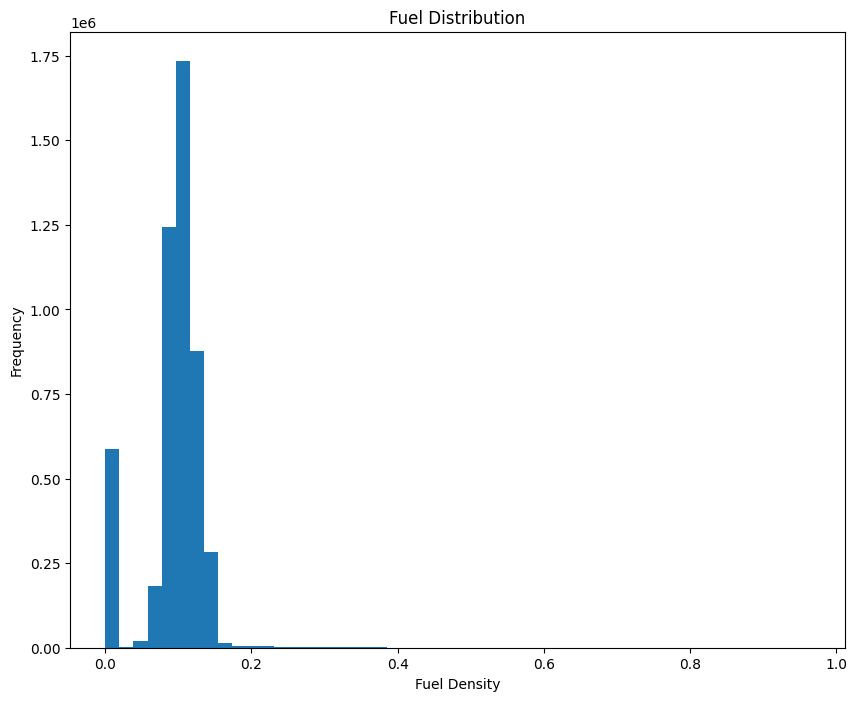

In [33]:
plt.figure(figsize=(10,8))

plt.hist(fuel_map.flatten(), bins=50)

plt.title("Fuel Distribution")

plt.xlabel("Fuel Density")

plt.ylabel("Frequency")

plt.show()

In [34]:
sparse_fuel_mask = fuel_map < 0.15

moderate_fuel_mask = (fuel_map >= 0.15) & (fuel_map < 0.4)

dense_fuel_mask = fuel_map >= 0.4

In [35]:
import json

metadata = {
    "dataset": "MODIS MOD13Q1",
    "region": "Saudi Eastern Province",
    "source_resolution_m": 250,
    "grid_sizes": [32, 64],
    "representation": "fuel density",
    "fuel_conversion": "clip_ndvi_0_1"
}

metadata_path = f"{GRID_BASE}/fuel_metadata.json"

with open(metadata_path, "w") as f:
    json.dump(metadata, f, indent=4)

print("Fuel metadata saved.")

Fuel metadata saved.
